In [1]:
!nvidia-smi

Tue May  5 12:55:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.45.03              Driver Version: 595.71         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090        On  |   00000000:01:00.0 Off |                  N/A |
|  0%   41C    P8             29W /  390W |     433MiB /  24576MiB |     10%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import random
import matplotlib.pyplot as plt

import tensorflow as tf

2026-05-05 12:55:14.509733: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-05 12:55:14.518792: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777978514.529207   53372 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777978514.532515   53372 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777978514.540825   53372 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [4]:
tf.config.list_physical_devices()

2026-05-05 12:55:16.077571: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

## Load dataset

In [5]:
def load_paths(filepath):
    lines = []
    with open(filepath, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
    
    base_dir = os.path.dirname(filepath) + '/HR/' + lines[0]
    seq_count = len(os.listdir(base_dir))

    result = [""] * seq_count * len(lines) * 7
    print(len(result))
    for i, line in enumerate(lines):
        for j in range(seq_count):
            for k in range(7):
                index = i * seq_count * 7 + j * 7 + k
                result[index] = os.path.join(f"{line}/{j}/im{k+1}.png")
    return result

In [6]:
train_paths = load_paths('/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/train.txt')
val_paths = load_paths('/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/test.txt')

452284
54768


In [7]:
def create_sr_dataset(
    root_path: str, 
    relative_paths: list[str], 
    batch_size: int = 32,
    is_training: bool = True,
    shuffle_buffer_size: int = 1000
):
    """
    Creates a lazy tf.data.Dataset for Super Resolution.
    
    Args:
        root_path: The base directory containing 'LR' and 'HR' folders.
        relative_paths: List of filenames/relative paths of the images.
        batch_size: The batch size for the dataset.
        is_training: If True, shuffles the dataset. If False, keeps original order for validation/testing.
        shuffle_buffer_size: The number of elements to maintain in the shuffle buffer.
    """
    paths_ds = tf.data.Dataset.from_tensor_slices(relative_paths)
    
    # Shuffle early in the pipeline if this is a training dataset
    if is_training:
        # Buffer size should ideally be larger than the batch size or the full dataset size
        # if memory permits, to ensure true randomness.
        paths_ds = paths_ds.shuffle(buffer_size=shuffle_buffer_size, reshuffle_each_iteration=True)
    
    def process_path(rel_path):
        # Construct the full paths by joining the root, subfolder, and relative path
        lr_path = tf.strings.join([root_path, 'LR', rel_path], separator=os.sep)
        hr_path = tf.strings.join([root_path, 'HR', rel_path], separator=os.sep)
        
        # Read the raw files (lazy loading)
        lr_img = tf.io.read_file(lr_path)
        hr_img = tf.io.read_file(hr_path)
        
        # Decode the images (adjust channels to 1 if using grayscale)
        lr_img = tf.image.decode_image(lr_img, channels=3, expand_animations=False)
        hr_img = tf.image.decode_image(hr_img, channels=3, expand_animations=False)
        
        # Convert to float32 and normalize to [0, 1] range
        lr_img = tf.cast(lr_img, tf.float32) / 255.0
        hr_img = tf.cast(hr_img, tf.float32) / 255.0
        
        return lr_img, hr_img

    # Use map to lazily load and transform the images automatically
    dataset = paths_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Batch the dataset
    dataset = dataset.batch(batch_size, drop_remainder=is_training)
    
    # Prefetch data to the GPU/Accelerator to prevent I/O bottlenecks
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return dataset

In [8]:

root_dir = "/mnt/c/Users/henrik/Downloads/vimeo90k_upscale/"
random.seed(42)
train_files = random.sample(train_paths, int(len(train_paths) * 1))
val_files = random.sample(val_paths, int(len(val_paths) * 1))

# Training dataset (Shuffled and drops incomplete batches)
train_ds = create_sr_dataset(root_dir, train_files, batch_size=32, is_training=True)
# 
# # Validation dataset (Not shuffled, keeps all data)
val_ds = create_sr_dataset(root_dir, val_files, batch_size=32, is_training=False)

## Metrics

In [9]:
def psnr_metric(y_true, y_pred):
    # Calculate PSNR manually to avoid Keras graph-mode Assert issues in tf.image.psnr
    # We add a small epsilon (1e-10) to the MSE to prevent the result from becoming 'inf'
    mse = tf.reduce_mean(tf.square(y_true - y_pred), axis=[1, 2, 3])
    # PSNR = 10 * log10(max_val^2 / MSE). Here max_val is 1.0.
    # tf.math.log is natural log, so we divide by log(10) to get log10.
    return 10.0 * (tf.math.log(1.0 / (mse + 1e-10)) / tf.math.log(10.0))

def ssmi_metric(y_true, y_pred):
    # Calculate SSIM manually to avoid Keras graph-mode Assert issues in tf.image.ssim
    # We add a small epsilon (1e-10) to prevent the result from becoming NaN
    ssim = tf.image.ssim(y_true, y_pred, max_val=1.0)
    return ssim

def luminance_weighted_loss(weight_y=0.8, weight_uv=0.1):
    if weight_y + 2 * weight_uv != 1.0:
        raise ValueError("Weights must sum to 1.0 (weight_y + 2 * weight_uv = 1.0)")
    def loss(y_true, y_pred):
        # Convert RGB tensors to YUV space
        # Note: tf.image.rgb_to_yuv expects values in the [0, 1] range
        yuv_true = tf.image.rgb_to_yuv(y_true)
        yuv_pred = tf.image.rgb_to_yuv(y_pred)

        # Calculate Mean Squared Error per channel
        # yuv[..., 0] is Y, yuv[..., 1] is U, yuv[..., 2] is V
        mse_y = tf.reduce_mean(tf.square(yuv_true[..., 0] - yuv_pred[..., 0]))
        mse_u = tf.reduce_mean(tf.square(yuv_true[..., 1] - yuv_pred[..., 1]))
        mse_v = tf.reduce_mean(tf.square(yuv_true[..., 2] - yuv_pred[..., 2]))

        # Combine with custom weights
        total_loss = (weight_y * mse_y) + (weight_uv * mse_u) + (weight_uv * mse_v)
        return total_loss
        
    return loss
luminance_loss = luminance_weighted_loss(weight_y=0.8, weight_uv=0.1)

## Dummy model (nearest/bilinear/lanczos3/lanczos5)

In [10]:
def create_dummy_model(x_width, x_height, y_width, y_height, interpolation="bilinear"):
    inp = tf.keras.layers.Input(shape=(x_height, x_width, 3))
    out = tf.keras.layers.Resizing(y_height, y_width, interpolation=interpolation)(inp)
    model = tf.keras.Model(inputs=inp, outputs=out)
    return model

In [11]:
model_nearest = create_dummy_model(128, 128, 256, 256, "nearest")

model_nearest.compile(
    optimizer='adam', # Optimizer isn't actually used since no weights, but required for compile
    loss=luminance_loss,
    metrics=[psnr_metric, ssmi_metric]
)

In [12]:
model_bilinear = create_dummy_model(128, 128, 256, 256, "bilinear")

model_bilinear.compile(
    optimizer='adam', # Optimizer isn't actually used since no weights, but required for compile
    loss=luminance_loss,
    metrics=[psnr_metric, ssmi_metric]
)

In [13]:
model_lanczos3 = create_dummy_model(128, 128, 256, 256, "lanczos3")

model_lanczos3.compile(
    optimizer='adam', # Optimizer isn't actually used since no weights, but required for compile
    loss=luminance_loss,
    metrics=[psnr_metric, ssmi_metric]
)

In [14]:
model_lanczos5 = create_dummy_model(128, 128, 256, 256, "lanczos5")

model_lanczos5.compile(
    optimizer='adam', # Optimizer isn't actually used since no weights, but required for compile
    loss=luminance_loss,
    metrics=[psnr_metric, ssmi_metric]
)

In [15]:
model_bilinear.save('./models/upscale_0_bilinear.keras')

## Visualization

In [16]:
def visualize_dataset_element(dataset, index, model=None):
    """
    Fetches an element at the given index from the dataset.
    If a model is provided, shows LR, Upscaled (with PSNR), and HR images.
    Otherwise, displays just LR and HR.
    """
    # Unbatch to access by raw element index
    unbatched = dataset.unbatch()
    
    for lr, hr in unbatched.skip(index).take(1):
        lr_np = lr.numpy()
        hr_np = hr.numpy()
        
        if model is not None:
            # Predict requires a batch dimension
            lr_batch = tf.expand_dims(lr, 0)
            pred = model(lr_batch)
            
            # Squeeze batch dimension and clip to valid image range
            pred_img = tf.clip_by_value(pred[0], 0.0, 1.0)
            
            # Calculate PSNR
            psnr = tf.image.psnr(hr, pred_img, max_val=1.0).numpy()
            
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            axes[0].imshow(lr_np)
            axes[0].set_title(f"LR Input\n{lr_np.shape}")
            axes[0].axis('off')
            
            axes[1].imshow(pred_img.numpy())
            axes[1].set_title(f"Upscaled Output\nPSNR: {psnr:.2f} dB")
            axes[1].axis('off')
            
            axes[2].imshow(hr_np)
            axes[2].set_title(f"HR Target\n{hr_np.shape}")
            axes[2].axis('off')
            
        else:
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(lr_np)
            axes[0].set_title(f"LR Input\n{lr_np.shape}")
            axes[0].axis('off')
            
            axes[1].imshow(hr_np)
            axes[1].set_title(f"HR Target\n{hr_np.shape}")
            axes[1].axis('off')
            
        plt.tight_layout()
        plt.show()
        return

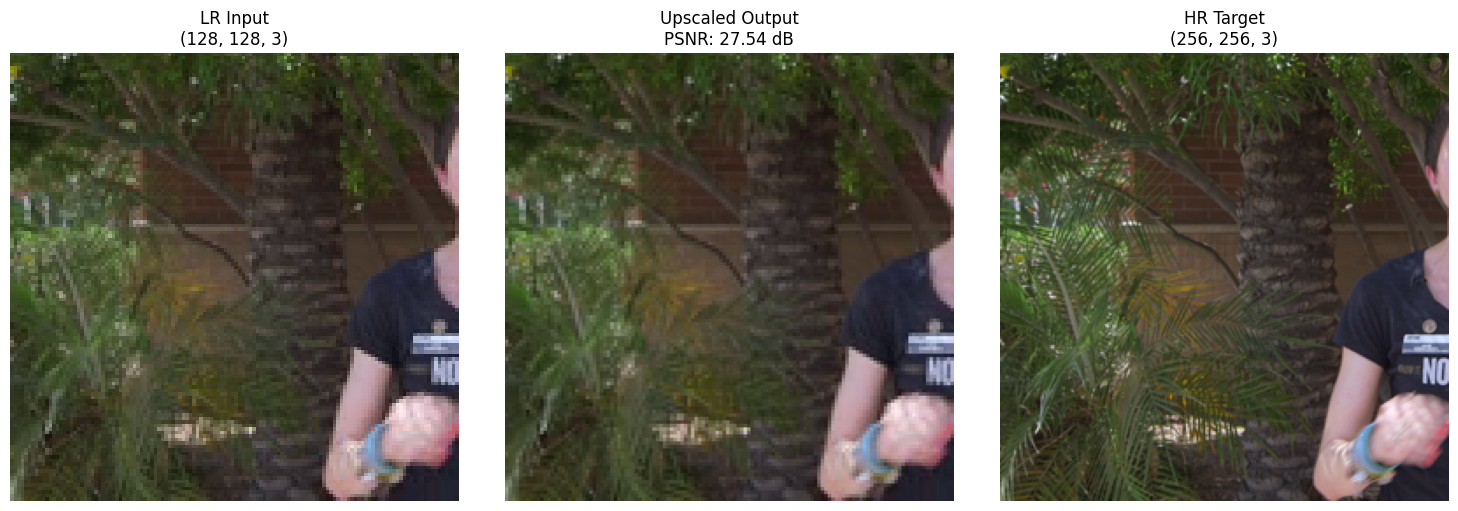

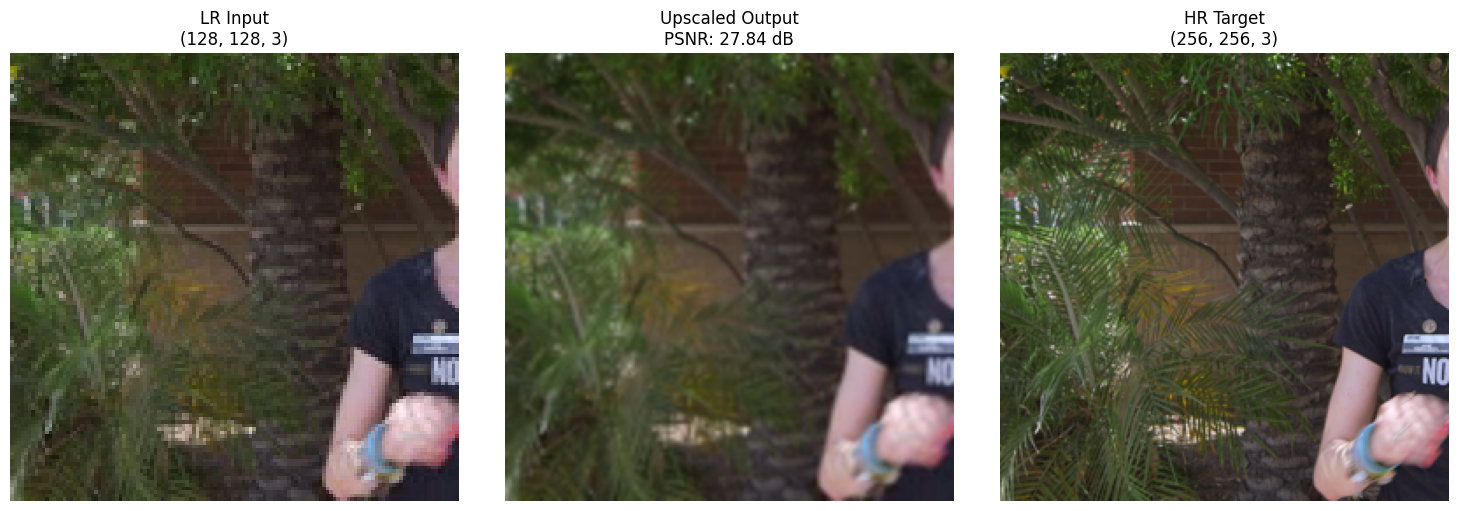

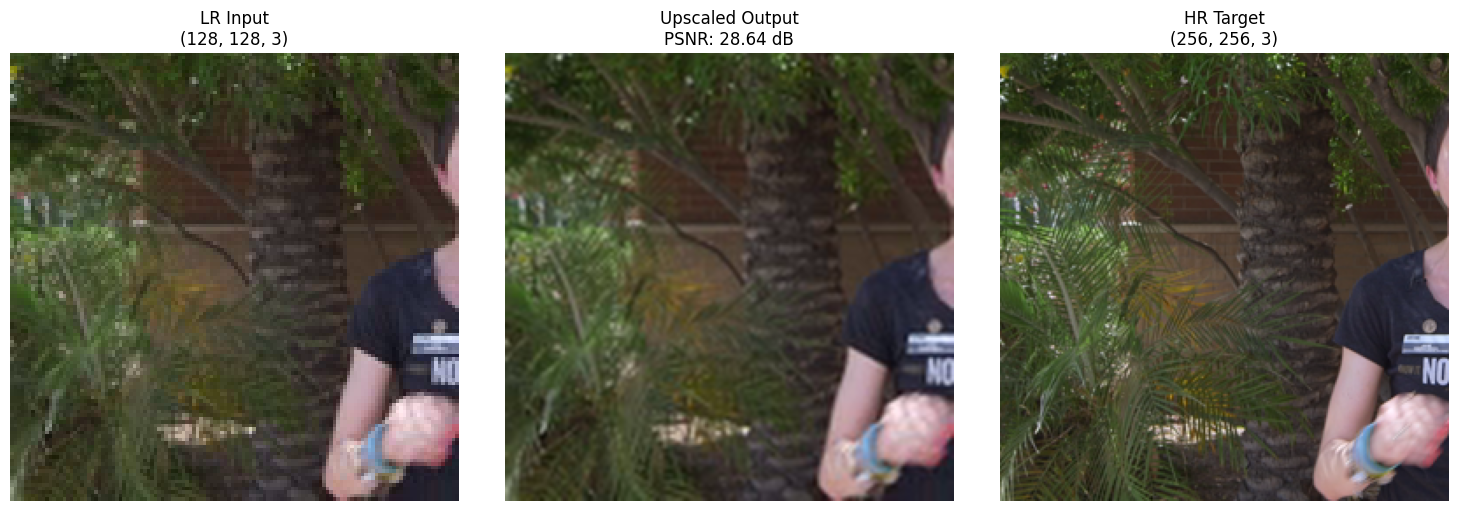

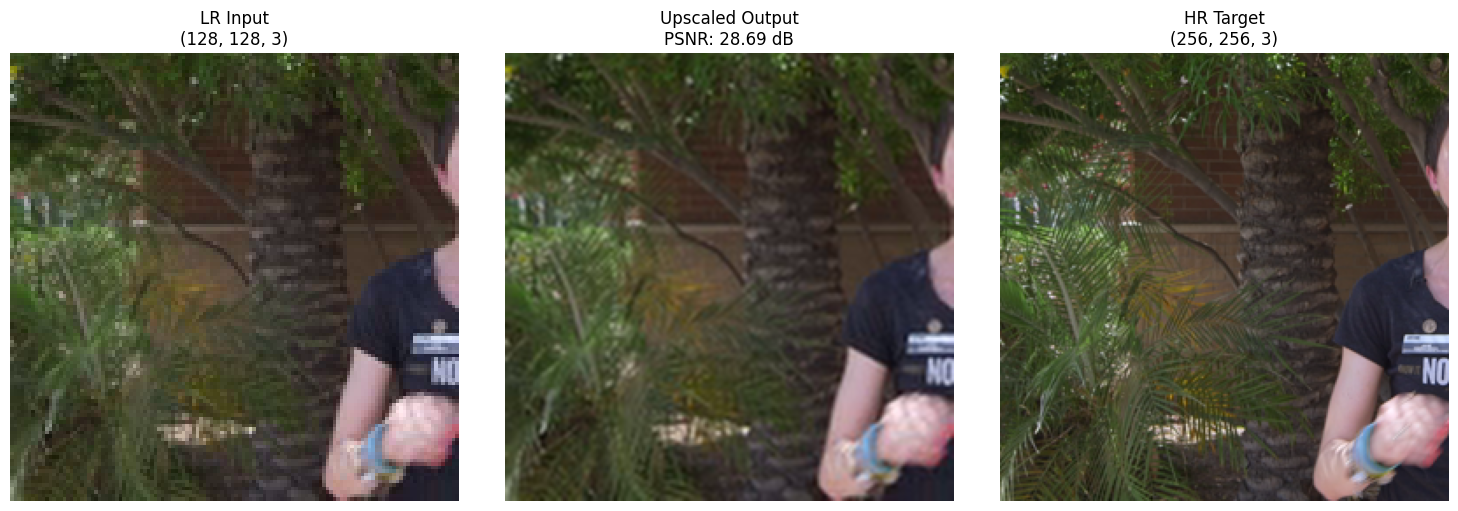

In [17]:
visualize_dataset_element(val_ds, index=0, model=model_nearest)
visualize_dataset_element(val_ds, index=0, model=model_bilinear)
visualize_dataset_element(val_ds, index=0, model=model_lanczos3)
visualize_dataset_element(val_ds, index=0, model=model_lanczos5)

## Validation

In [18]:
print("Evaluating nearest neighbor upscaling dummy model on the entire validation dataset...")

# 4. Use Keras built-in .evaluate() on the validation dataset (val_ds)
evaluation_results = model_nearest.evaluate(val_ds)

print("-" * 30)
print(f"Validation Mean Squared Error (Loss): {evaluation_results[0]:.4f}")
print(f"Validation Mean PSNR:                 {evaluation_results[1]:.2f} dB")
print(f"Validation Mean SSIM:                 {evaluation_results[2]:.4f}")
print("-" * 30)

Evaluating nearest neighbor upscaling dummy model on the entire validation dataset...
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 127s 74ms/step - loss: 0.0010 - psnr_metric: 29.8106 - ssmi_metric: 0.8513
------------------------------
Validation Mean Squared Error (Loss): 0.0010
Validation Mean PSNR:                 29.81 dB
Validation Mean SSIM:                 0.8513
------------------------------


In [19]:
print("Evaluating bilinear upscaling dummy model on the entire validation dataset...")

# 4. Use Keras built-in .evaluate() on the validation dataset (val_ds)
evaluation_results = model_bilinear.evaluate(val_ds)

print("-" * 30)
print(f"Validation Mean Squared Error (Loss): {evaluation_results[0]:.4f}")
print(f"Validation Mean PSNR:                 {evaluation_results[1]:.2f} dB")
print(f"Validation Mean SSIM:                 {evaluation_results[2]:.4f}")
print("-" * 30)

Evaluating bilinear upscaling dummy model on the entire validation dataset...
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 126s 74ms/step - loss: 8.5224e-04 - psnr_metric: 30.8667 - ssmi_metric: 0.8710
------------------------------
Validation Mean Squared Error (Loss): 0.0009
Validation Mean PSNR:                 30.87 dB
Validation Mean SSIM:                 0.8710
------------------------------


In [20]:
print("Evaluating lanczos3 upscaling dummy model on the entire validation dataset...")

# 4. Use Keras built-in .evaluate() on the validation dataset (val_ds)
evaluation_results = model_lanczos3.evaluate(val_ds)

print("-" * 30)
print(f"Validation Mean Squared Error (Loss): {evaluation_results[0]:.4f}")
print(f"Validation Mean PSNR:                 {evaluation_results[1]:.2f} dB")
print(f"Validation Mean SSIM:                 {evaluation_results[2]:.4f}")
print("-" * 30)

Evaluating lanczos3 upscaling dummy model on the entire validation dataset...
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 130s 76ms/step - loss: 7.2743e-04 - psnr_metric: 31.3987 - ssmi_metric: 0.8761
------------------------------
Validation Mean Squared Error (Loss): 0.0007
Validation Mean PSNR:                 31.40 dB
Validation Mean SSIM:                 0.8761
------------------------------


In [21]:
print("Evaluating lanczos5 upscaling dummy model on the entire validation dataset...")

# 4. Use Keras built-in .evaluate() on the validation dataset (val_ds)
evaluation_results = model_lanczos5.evaluate(val_ds)

print("-" * 30)
print(f"Validation Mean Squared Error (Loss): {evaluation_results[0]:.4f}")
print(f"Validation Mean PSNR:                 {evaluation_results[1]:.2f} dB")
print(f"Validation Mean SSIM:                 {evaluation_results[2]:.4f}")
print("-" * 30)

Evaluating lanczos5 upscaling dummy model on the entire validation dataset...
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 134s 78ms/step - loss: 7.1916e-04 - psnr_metric: 31.4271 - ssmi_metric: 0.8759
------------------------------
Validation Mean Squared Error (Loss): 0.0007
Validation Mean PSNR:                 31.43 dB
Validation Mean SSIM:                 0.8759
------------------------------
